In [15]:
import sys
sys.path.insert(0, '..')
from dependencies import *

envelopes_log = eelbrain.load.unpickle(PROCESSED_PREDICTOR_DIR / f'~processed_envelopes-log.pickle')
durations = get_durations(envelopes_log)
models = get_models()

In [16]:
subject = 'S05'
model = 'envelope_log_8band'
trf_decoder = eelbrain.load.unpickle(TRF_DIR / f'{subject}' / f'{subject} decoder-{model}.pickle')
eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')
subject_model_predictor = eelbrain.load.unpickle(PREDICTOR_DIR / f'~concatenated_predictors.pickle')
envelope = subject_model_predictor[subject][model]

#print(trf_s05.h_scaled)
#print(envelopes_log)

predicted_envelope = eelbrain.convolve(trf_decoder.h_scaled, eeg).x
#print(predicted_envelope)
#print(envelope_data)

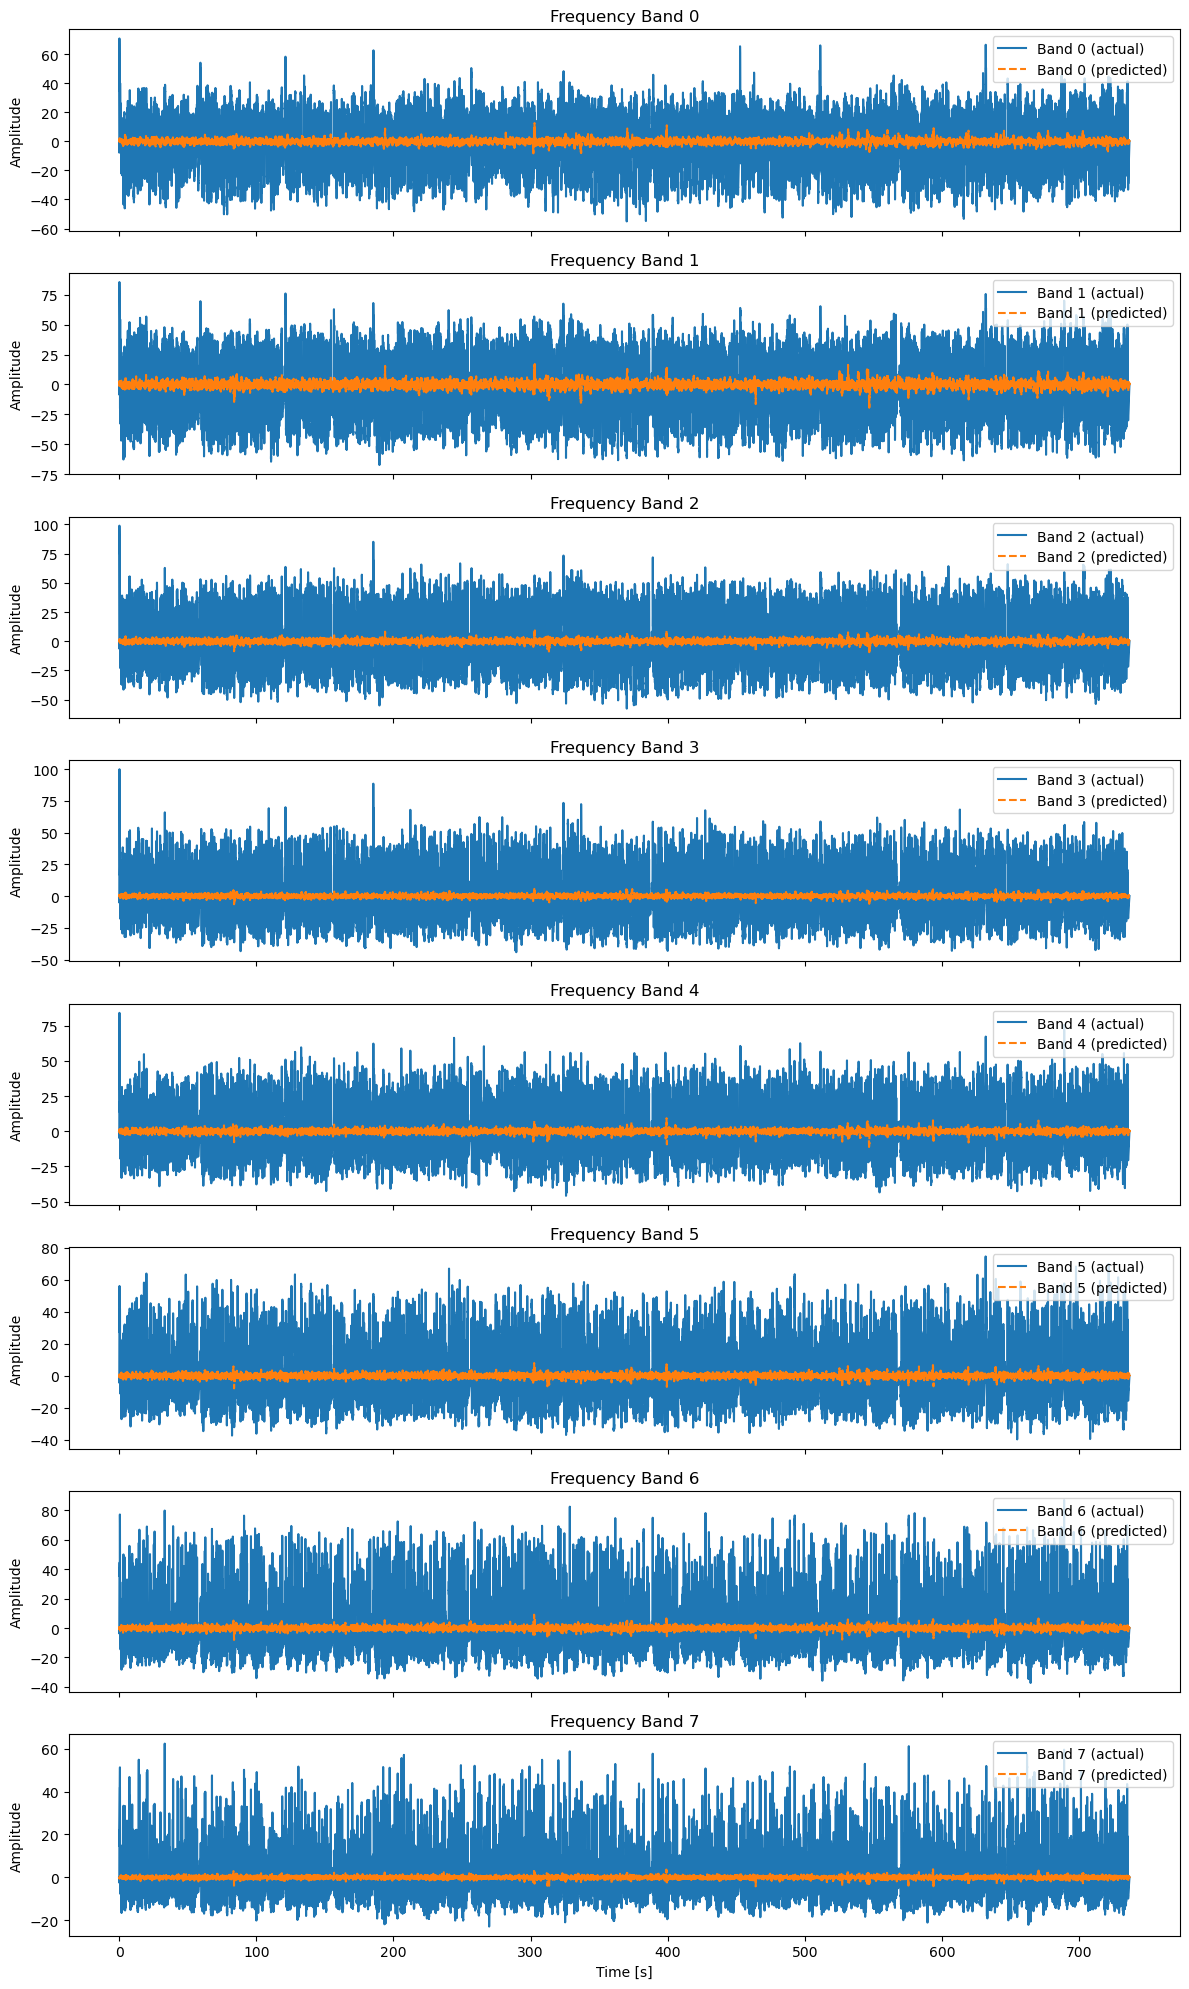

Proportion explained per band:
[0.01076928 0.01294224 0.00884639 0.00709279 0.00953843 0.00922926
 0.00898697 0.0068241 ]


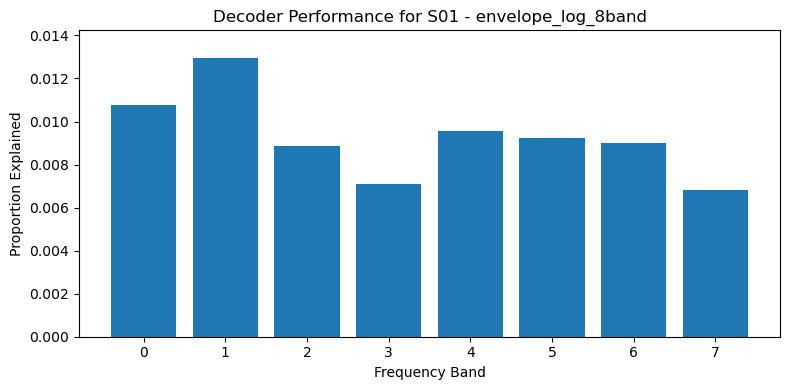

In [20]:
# Convert NDVars to numpy arrays for plotting
envelope_data = envelope.x             # shape: (frequency, time)
time = envelope.time

# Number of frequency bands / predictors
n_bands = envelope_data.shape[0]

# ————————————————————————————————————————————————————————————————
# Create subplots: 1 row per band (or 2x4 if you prefer)
fig, axes = plt.subplots(n_bands, 1, figsize=(12, 2.5*n_bands), sharex=True)

#predicted_envelope = predicted_envelope * (envelope_data.std(axis=1) / predicted_envelope.std(axis=1))[:, None]

for i in range(n_bands):
    ax = axes[i]
    ax.plot(time, envelope_data[i, :], label=f'Band {i} (actual)')
    ax.plot(time, predicted_envelope[i, :], '--', label=f'Band {i} (predicted)')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Frequency Band {i}')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

# ————————————————————————————————————————————————————————————————
# Compute proportion explained per band using np.abs()
proportion_explained = 1 - (np.abs(envelope_data - predicted_envelope).sum(axis=1) /
                            np.abs(envelope_data).sum(axis=1))
print(f'Proportion explained per band:\n{proportion_explained}')

# ————————————————————————————————————————————————————————————————
# Bar plot of proportion explained
plt.figure(figsize=(8, 4))
plt.bar(range(n_bands), proportion_explained)
plt.xlabel('Frequency Band')
plt.ylabel('Proportion Explained')
plt.title(f'Decoder Performance for {subject} - {model}')
plt.xticks(range(n_bands))
plt.ylim(0, max(proportion_explained)*1.1)
plt.tight_layout()
plt.show()

